# 03 — Loan Approval Prediction

Evaluate approval probability and the application decision using the production model and the configured 0.50 threshold.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('Project root:', ROOT)

Project root: c:\Users\Dinesh more\OneDrive\Desktop\bank-loan-credit-risk-analysis\bank-loan-credit-risk-analysis


In [2]:
import json
import joblib
import pandas as pd
import numpy as np

from src.pipeline_utils import clean_common, feature_frame, CONFIG

models = {
    'loan_amount': joblib.load(ROOT/'models/loan_amount.joblib'),
    'loan_approval': joblib.load(ROOT/'models/loan_approval.joblib'),
    'credit_score': joblib.load(ROOT/'models/credit_score.joblib'),
    'credit_risk': joblib.load(ROOT/'models/credit_risk.joblib'),
}
print('Loaded:', ', '.join(models))

c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.8.0 when using version 1.7.2. This might lead 

Loaded: loan_amount, loan_approval, credit_score, credit_risk


c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

loan=clean_common(pd.read_csv(ROOT/'data/raw/loan_data.csv'))
X=feature_frame(loan, CONFIG['features']['loan_approval'])
y=loan.loan_status.eq('Approved').astype(int)
_, X_test, _, y_test=train_test_split(X,y,test_size=.20,random_state=42,stratify=y)
prob=models['loan_approval'].predict_proba(X_test)[:,1]
pred=(prob>=CONFIG['thresholds']['approval_probability']).astype(int)
print('Accuracy:',accuracy_score(y_test,pred))
print('F1:',f1_score(y_test,pred))
print('ROC-AUC:',roc_auc_score(y_test,prob))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))
print(classification_report(y_test,pred,target_names=['Rejected','Approved']))

Accuracy: 0.7733333333333333
F1: 0.3182957393483709
ROC-AUC: 0.7426283950419577
Confusion matrix:
 [[1729  135]
 [ 409  127]]
              precision    recall  f1-score   support

    Rejected       0.81      0.93      0.86      1864
    Approved       0.48      0.24      0.32       536

    accuracy                           0.77      2400
   macro avg       0.65      0.58      0.59      2400
weighted avg       0.74      0.77      0.74      2400



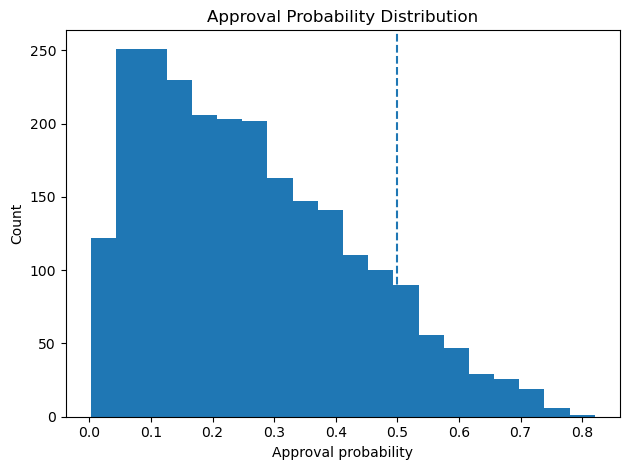

In [4]:
import matplotlib.pyplot as plt

plt.hist(prob,bins=20)
plt.axvline(CONFIG['thresholds']['approval_probability'], linestyle='--')
plt.xlabel('Approval probability'); plt.ylabel('Count'); plt.title('Approval Probability Distribution'); plt.tight_layout(); plt.show()

## Decision rule
`Approved` is returned when approval probability is at least the configured threshold; otherwise `Rejected`.